# Creusement d'un tunnel au tunnelier · 2. Prédire le tassement

Peut-on prédire le tassement maximal en surface d'un anneau à partir des paramètres de pilotage du tunnelier et des paramètres du sol ?

Démarche : une régression linéaire comme référence, deux méthodes de sélection de variables (corrélation de Pearson et importance par permutation), puis trois familles de modèles à base d'arbres, réglées par validation croisée à 10 plis.

> **Données synthétiques.** Les données réelles du projet sont confidentielles. Ce notebook tourne sur un jeu synthétique de même structure, créé par `scripts/make_synthetic_data.py`. Les chiffres et les figures ci-dessous montrent la démarche, pas les résultats du vrai tunnel.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# données synthétiques par défaut ; TUNNEL_DATA=chemin pour les vraies données (équipe seulement)
DATA = Path(os.environ.get("TUNNEL_DATA", "../data/synthetic"))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

SEED = 42

## 1. Le jeu de données

Une ligne par anneau instrumenté : le tassement mesuré, six paramètres de pilotage du tunnelier et six paramètres de sol homogénéisés.

In [2]:
tunnelier = pd.read_csv(DATA / "parametre_tunnelier.csv")
sol = pd.read_csv(DATA / "stratigraphie_homogenisee.csv")
smax = pd.read_csv(DATA / "smax.csv")

tunnelier["P_front"] = tunnelier["CapteurPressionsTerreFront1[bar]"]
tunnelier["PressionInjectionMortier"] = tunnelier[
    [f"PressionInjectionMortier{a}[bar]" for a in ("A1", "A2", "A5", "A6")]
].mean(axis=1)
tunnelier = tunnelier.rename(columns={
    "Avance_RDC[mm/mn]": "Avance_RDC",
    "Couple_RDC[kN.m]": "Couple_RDC",
    "PousseeTotale[kN]": "PousseeTotale",
    "QuantiteMortierInjecteTotale[m3]": "QuantiteMortier",
})
sol = sol.rename(columns={
    "gamma_h[kN/m3]": "gamma_h", "E_M[MPa]": "E_M", "alpha[]": "alpha",
    "c'[kPa]": "c", "phi'[°]": "phi", "K0[]": "K0",
})

VARIABLES_TUNNELIER = ["Avance_RDC", "Couple_RDC", "P_front", "PousseeTotale",
                       "PressionInjectionMortier", "QuantiteMortier"]
VARIABLES_SOL = ["gamma_h", "E_M", "alpha", "c", "phi", "K0"]
VARIABLES = VARIABLES_TUNNELIER + VARIABLES_SOL

df = (
    smax[["id_anneau", "smax"]]
    .merge(tunnelier[["id_anneau"] + VARIABLES_TUNNELIER], on="id_anneau")
    .merge(sol[["id_anneau"] + VARIABLES_SOL], on="id_anneau")
)
X, y = df[VARIABLES], df["smax"]
print(f"{len(df)} anneaux, {X.shape[1]} variables, "
      f"{int(X.isna().any(axis=1).sum())} anneaux avec une valeur manquante (imputée par la médiane)")

424 anneaux, 12 variables, 6 anneaux avec une valeur manquante (imputée par la médiane)


## 2. Découpage et référence linéaire

60 % entraînement, 20 % validation, 20 % test. Le jeu de test n'est utilisé qu'une fois, pour la synthèse finale. Les valeurs manquantes sont imputées dans le pipeline, donc à partir du seul jeu d'entraînement.

In [3]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=SEED)
CV = KFold(n_splits=10, shuffle=True, random_state=SEED)


def pipeline(modele):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), modele)


def scores(modele, X_eval, y_eval):
    prediction = modele.predict(X_eval)
    return {
        "R²": r2_score(y_eval, prediction),
        "RMSE (mm)": np.sqrt(mean_squared_error(y_eval, prediction)),
        "MAE (mm)": mean_absolute_error(y_eval, prediction),
    }


ridge = pipeline(Ridge(alpha=1.0)).fit(X_train, y_train)
pd.Series(scores(ridge, X_val, y_val)).round(3).rename("Ridge, validation")

R²           0.770
RMSE (mm)    0.725
MAE (mm)     0.563
Name: Ridge, validation, dtype: float64

## 3. Sélection des variables

On garde six variables sur douze, choisies de deux façons :

- **Pearson** : les six variables les plus corrélées, en valeur absolue, au tassement ;
- **Permutation** : on entraîne une forêt aléatoire sur toutes les variables, puis on mélange chaque variable du jeu de validation et on mesure la hausse de l'erreur. Contrairement à Pearson, cette méthode capte aussi les effets non linéaires et les interactions.

Les deux sélections sont faites sans toucher au jeu de test.

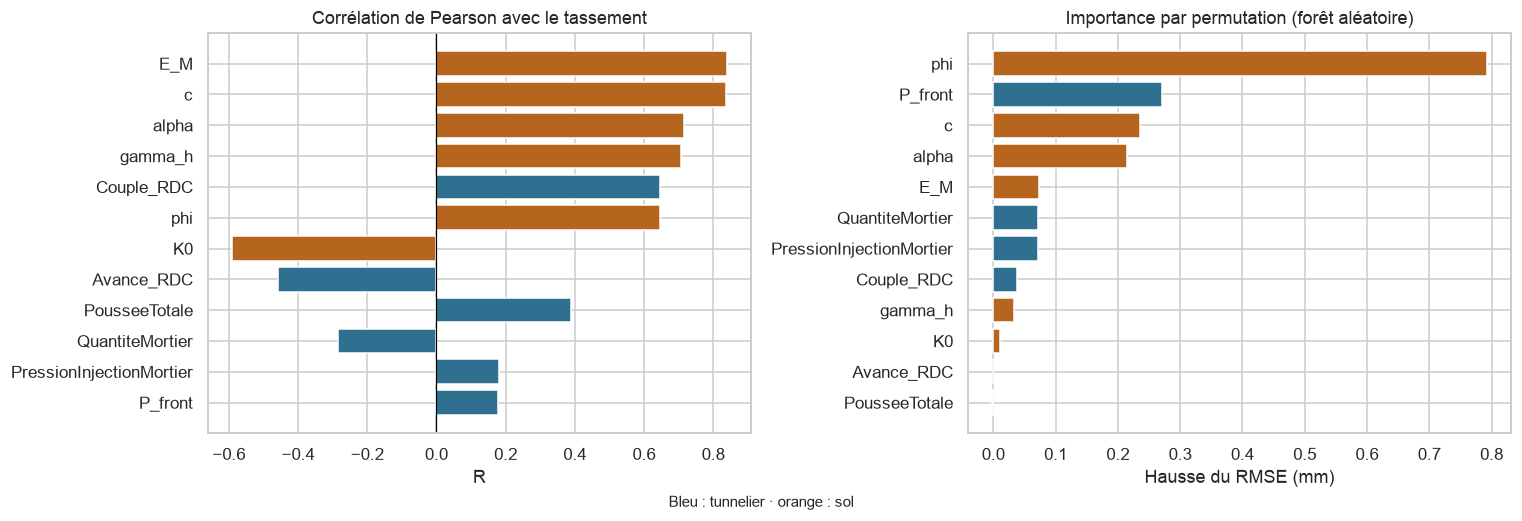

,Pearson,Permutation
1,E_M,phi
2,c,P_front
3,alpha,c
4,gamma_h,alpha
5,Couple_RDC,E_M
6,phi,QuantiteMortier


In [4]:
pearson = (pd.concat([X_trainval, y_trainval], axis=1).corr()["smax"].drop("smax")
           .sort_values(key=abs, ascending=False))
TOP_PEARSON = pearson.index[:6].tolist()

foret_complete = pipeline(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1))
foret_complete.fit(X_train, y_train)
permutation = permutation_importance(foret_complete, X_val, y_val, scoring="neg_root_mean_squared_error",
                                     n_repeats=30, random_state=SEED, n_jobs=-1)
importance = pd.Series(permutation.importances_mean, index=VARIABLES).sort_values(ascending=False)
TOP_PERMUTATION = importance.index[:6].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
couleurs = ["#2f6f8f" if v in VARIABLES_TUNNELIER else "#b5651d" for v in pearson.index]
axes[0].barh(pearson.index[::-1], pearson.values[::-1], color=couleurs[::-1])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set(title="Corrélation de Pearson avec le tassement", xlabel="R")
couleurs = ["#2f6f8f" if v in VARIABLES_TUNNELIER else "#b5651d" for v in importance.index]
axes[1].barh(importance.index[::-1], importance.values[::-1], color=couleurs[::-1])
axes[1].set(title="Importance par permutation (forêt aléatoire)", xlabel="Hausse du RMSE (mm)")
fig.suptitle("Bleu : tunnelier · orange : sol", fontsize=10, y=0.02)
fig.tight_layout()
plt.show()

pd.DataFrame({"Pearson": TOP_PEARSON, "Permutation": TOP_PERMUTATION}, index=range(1, 7))

## 4. Arbre de décision : où commence le surapprentissage ?

On fait varier la profondeur maximale de l'arbre, pour chacune des deux sélections, et on compare l'erreur d'entraînement à l'erreur de validation croisée.

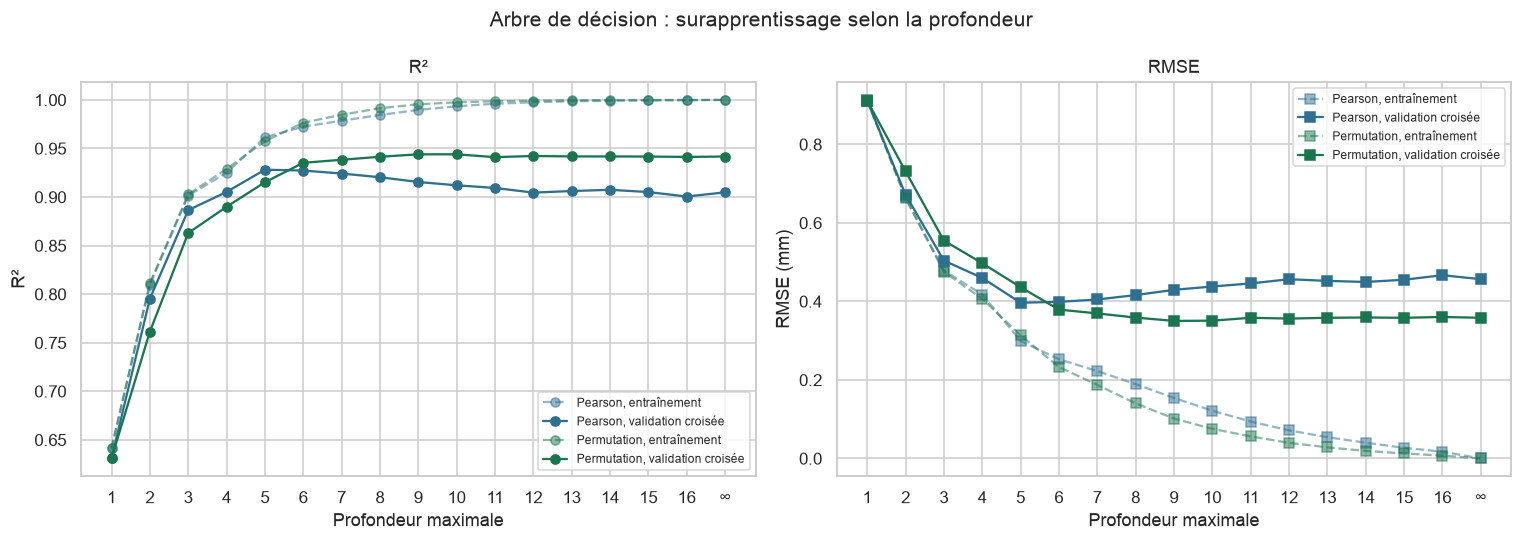

{'Pearson': 5, 'Permutation': 9}

In [5]:
PROFONDEURS = list(range(1, 17)) + [None]


def balayage_arbre(variables):
    grille = GridSearchCV(
        pipeline(DecisionTreeRegressor(random_state=SEED)),
        {"decisiontreeregressor__max_depth": PROFONDEURS},
        cv=CV, scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error"}, refit="RMSE",
        return_train_score=True,
    )
    return grille.fit(X_trainval[variables], y_trainval)


arbres = {"Pearson": balayage_arbre(TOP_PEARSON), "Permutation": balayage_arbre(TOP_PERMUTATION)}

etiquettes = [str(p) if p is not None else "∞" for p in PROFONDEURS]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (nom, grille), couleur in zip(arbres.items(), ["#2f6f8f", "#1b7650"]):
    res = grille.cv_results_
    axes[0].plot(etiquettes, res["mean_train_R2"], ls="--", marker="o", color=couleur, alpha=0.5, label=f"{nom}, entraînement")
    axes[0].plot(etiquettes, res["mean_test_R2"], marker="o", color=couleur, label=f"{nom}, validation croisée")
    axes[1].plot(etiquettes, -res["mean_train_RMSE"], ls="--", marker="s", color=couleur, alpha=0.5, label=f"{nom}, entraînement")
    axes[1].plot(etiquettes, -res["mean_test_RMSE"], marker="s", color=couleur, label=f"{nom}, validation croisée")
axes[0].set(title="R²", xlabel="Profondeur maximale", ylabel="R²")
axes[1].set(title="RMSE", xlabel="Profondeur maximale", ylabel="RMSE (mm)")
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle("Arbre de décision : surapprentissage selon la profondeur", fontsize=14)
fig.tight_layout()
plt.show()

{nom: grille.best_params_["decisiontreeregressor__max_depth"] for nom, grille in arbres.items()}

## 5. Forêt aléatoire

Deux étapes. On cherche d'abord le nombre d'arbres au-delà duquel l'erreur ne baisse plus, puis on règle ensemble la profondeur et le nombre minimal d'échantillons pour diviser un nœud, en tirant 4 variables au hasard à chaque division.

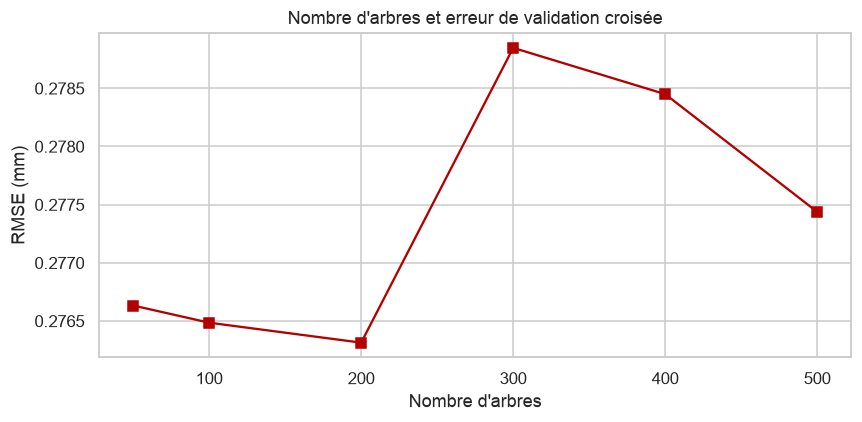

In [6]:
grille_nb_arbres = GridSearchCV(
    pipeline(RandomForestRegressor(max_depth=10, random_state=SEED, n_jobs=-1)),
    {"randomforestregressor__n_estimators": [50, 100, 200, 300, 400, 500]},
    cv=CV, scoring="neg_root_mean_squared_error",
).fit(X_trainval[TOP_PERMUTATION], y_trainval)

nb_arbres = grille_nb_arbres.cv_results_["param_randomforestregressor__n_estimators"].data.astype(int)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nb_arbres, -grille_nb_arbres.cv_results_["mean_test_score"], marker="s", color="#b30000")
ax.set(title="Nombre d'arbres et erreur de validation croisée", xlabel="Nombre d'arbres", ylabel="RMSE (mm)")
fig.tight_layout()
plt.show()

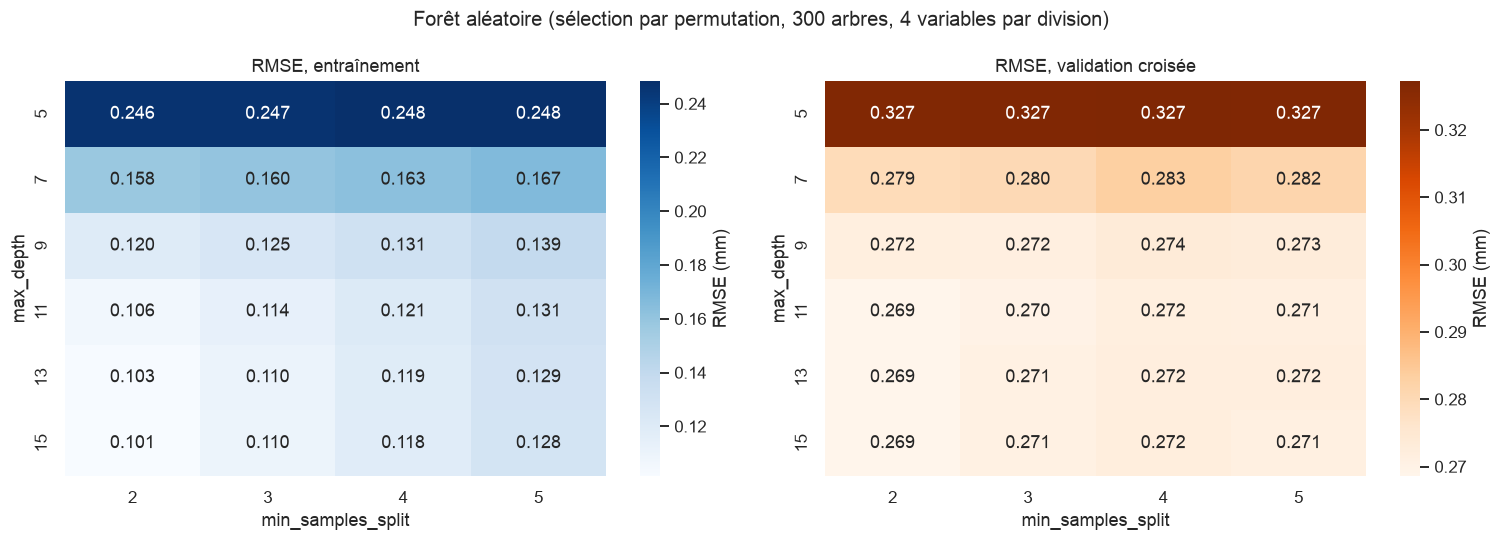

{'Pearson': {'randomforestregressor__max_depth': 7,
  'randomforestregressor__min_samples_split': 4},
 'Permutation': {'randomforestregressor__max_depth': 11,
  'randomforestregressor__min_samples_split': 2}}

In [7]:
GRILLE_FORET = {
    "randomforestregressor__max_depth": [5, 7, 9, 11, 13, 15],
    "randomforestregressor__min_samples_split": [2, 3, 4, 5],
}


def reglage_foret(variables):
    grille = GridSearchCV(
        pipeline(RandomForestRegressor(n_estimators=300, max_features=4, random_state=SEED, n_jobs=-1)),
        GRILLE_FORET, cv=CV, scoring="neg_root_mean_squared_error", return_train_score=True,
    )
    return grille.fit(X_trainval[variables], y_trainval)


forets = {"Pearson": reglage_foret(TOP_PEARSON), "Permutation": reglage_foret(TOP_PERMUTATION)}

res = pd.DataFrame(forets["Permutation"].cv_results_)
cartes = {
    titre: res.pivot(index="param_randomforestregressor__max_depth",
                     columns="param_randomforestregressor__min_samples_split", values=colonne) * -1
    for titre, colonne in [("Entraînement", "mean_train_score"), ("Validation croisée", "mean_test_score")]
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (titre, carte), palette in zip(axes, cartes.items(), ["Blues", "Oranges"]):
    sns.heatmap(carte, annot=True, fmt=".3f", cmap=palette, ax=ax, cbar_kws={"label": "RMSE (mm)"})
    ax.set(title=f"RMSE, {titre.lower()}", xlabel="min_samples_split", ylabel="max_depth")
fig.suptitle("Forêt aléatoire (sélection par permutation, 300 arbres, 4 variables par division)", fontsize=13)
fig.tight_layout()
plt.show()

{nom: grille.best_params_ for nom, grille in forets.items()}

## 6. XGBoost

Le boosting de gradient construit les arbres les uns après les autres, chacun corrigeant les erreurs des précédents.

In [8]:
xgb = GridSearchCV(
    pipeline(XGBRegressor(random_state=SEED, n_jobs=-1)),
    {
        "xgbregressor__n_estimators": [100, 200, 400],
        "xgbregressor__learning_rate": [0.03, 0.1, 0.2],
        "xgbregressor__max_depth": [3, 5, 7],
    },
    cv=CV, scoring="neg_root_mean_squared_error",
).fit(X_trainval[TOP_PERMUTATION], y_trainval)
xgb.best_params_

{'xgbregressor__learning_rate': 0.1,
 'xgbregressor__max_depth': 3,
 'xgbregressor__n_estimators': 200}

## 7. Synthèse sur le jeu de test

Chaque modèle est évalué une seule fois sur les 20 % d'anneaux mis de côté au départ.

In [9]:
ridge_final = pipeline(Ridge(alpha=1.0)).fit(X_trainval, y_trainval)
modeles = {
    "Ridge (12 variables)": (ridge_final, VARIABLES),
    "Arbre de décision (permutation)": (arbres["Permutation"], TOP_PERMUTATION),
    "Forêt aléatoire (Pearson)": (forets["Pearson"], TOP_PEARSON),
    "Forêt aléatoire (permutation)": (forets["Permutation"], TOP_PERMUTATION),
    "XGBoost (permutation)": (xgb, TOP_PERMUTATION),
}
synthese = pd.DataFrame(
    {nom: scores(modele, X_test[variables], y_test) for nom, (modele, variables) in modeles.items()}
).T.sort_values("R²", ascending=False)
synthese.round(3)

,R²,RMSE (mm),MAE (mm)
Forêt aléatoire (permutation),0.964,0.274,0.207
XGBoost (permutation),0.944,0.344,0.245
Forêt aléatoire (Pearson),0.927,0.392,0.300
Arbre de décision (permutation),0.923,0.401,0.282
Ridge (12 variables),0.817,0.620,0.520


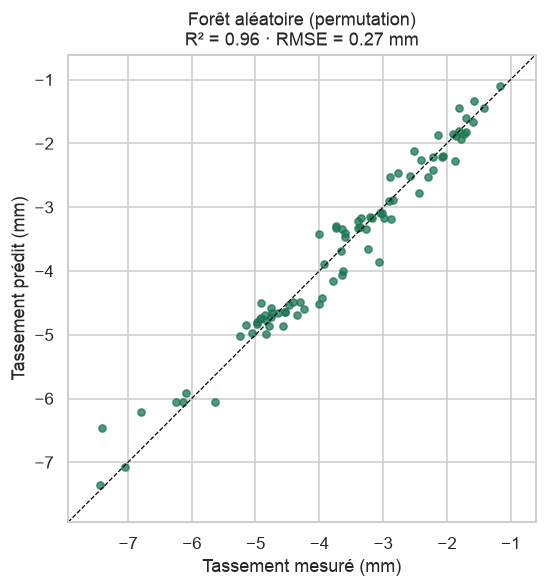

In [10]:
meilleur = synthese.index[0]
modele, variables = modeles[meilleur]
prediction = modele.predict(X_test[variables])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, prediction, s=22, alpha=0.75, color="#1b7650")
bornes = [min(y_test.min(), prediction.min()) - 0.5, max(y_test.max(), prediction.max()) + 0.5]
ax.plot(bornes, bornes, color="black", lw=0.8, ls="--")
ax.set(xlim=bornes, ylim=bornes, xlabel="Tassement mesuré (mm)", ylabel="Tassement prédit (mm)",
       title=f"{meilleur}\nR² = {synthese.loc[meilleur, 'R²']:.2f} · RMSE = {synthese.loc[meilleur, 'RMSE (mm)']:.2f} mm")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

**Lecture.** On compare chaque modèle à la régression ridge, et les deux sélections de variables à modèle égal. Sur les données réelles, les modèles à base d'arbres dépassaient nettement la référence linéaire, et la forêt aléatoire avec sélection par permutation arrivait en tête.

## 8. Le modèle généralise-t-il à une zone jamais vue ?

*Section ajoutée lors de la publication du projet.*

Le tassement a été mesuré par zones instrumentées, et il varie peu d'un anneau à son voisin (voir le notebook d'exploration). Avec un découpage aléatoire, le jeu de test contient donc des anneaux presque identiques à des anneaux d'entraînement. Pour savoir si le modèle prédirait le tassement d'un nouveau tronçon, on met de côté une zone entière à chaque fois : chaque zone est prédite par un modèle qui ne l'a jamais vue. On compare au modèle le plus simple possible, qui prédit toujours le tassement moyen.

9 zones instrumentées


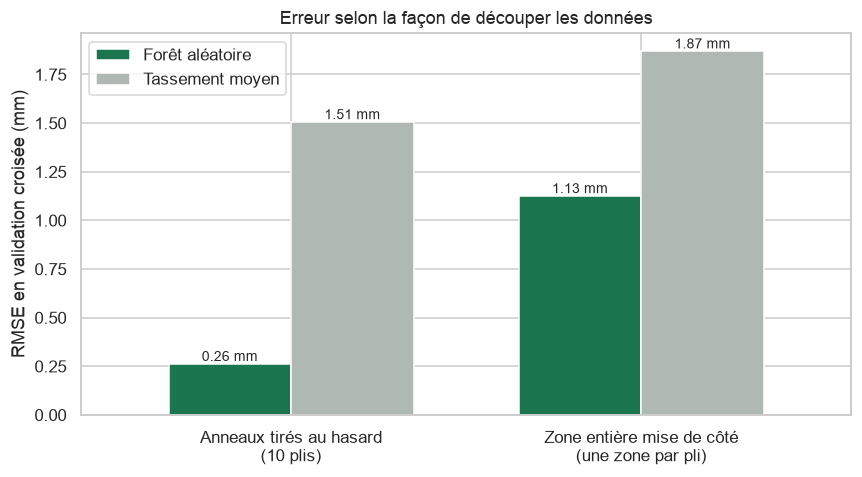

Modèle,Forêt aléatoire,Tassement moyen
Protocole,,
Anneaux tirés au hasard\n(10 plis),0.26,1.51
Zone entière mise de côté\n(une zone par pli),1.13,1.87


In [11]:
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_validate

# une zone instrumentée = une suite d'anneaux mesurés sans trou de plus de 100 m
pk = df["id_anneau"].map(pd.read_csv(DATA / "anneau.csv").set_index("id_anneau")["pk"])
zone = (pk.sort_values().diff() > 100).cumsum().reindex(df.index)
print(f"{zone.nunique()} zones instrumentées")

protocoles = {
    "Anneaux tirés au hasard\n(10 plis)": (KFold(n_splits=10, shuffle=True, random_state=SEED), None),
    "Zone entière mise de côté\n(une zone par pli)": (LeaveOneGroupOut(), zone),
}
candidats = {
    "Forêt aléatoire": clone(forets["Permutation"].best_estimator_),
    "Tassement moyen": DummyRegressor(strategy="mean"),
}
lignes = []
for protocole, (cv, groupes) in protocoles.items():
    for nom, modele in candidats.items():
        res = cross_validate(modele, X[TOP_PERMUTATION], y, cv=cv, groups=groupes,
                             scoring="neg_root_mean_squared_error")
        lignes.append({"Protocole": protocole, "Modèle": nom, "RMSE (mm)": -res["test_score"].mean()})
generalisation = pd.DataFrame(lignes).pivot(index="Protocole", columns="Modèle", values="RMSE (mm)")

fig, ax = plt.subplots(figsize=(8, 4.5))
generalisation[list(candidats)].plot.bar(ax=ax, color=["#1b7650", "#b0b8b4"], rot=0, width=0.7)
for conteneur in ax.containers:
    ax.bar_label(conteneur, fmt="%.2f mm", fontsize=9)
ax.set(xlabel="", ylabel="RMSE en validation croisée (mm)",
       title="Erreur selon la façon de découper les données")
ax.legend(title="")
fig.tight_layout()
plt.show()

generalisation.round(2)

**Lecture.** Si l'erreur « zone entière » est bien plus forte que l'erreur « au hasard », et proche de celle du tassement moyen, le modèle interpole entre anneaux voisins mais généralise mal à un tronçon nouveau. C'est ce qui s'est produit sur les données réelles.

Les variables et les hyperparamètres ont été choisis avec un découpage aléatoire : même le protocole par zones reste donc un peu optimiste.

## 9. Limites et pistes

- **Généralisation.** C'est le point principal, d'après la section 8 : pour prédire le tassement d'un nouveau tronçon, il faut des variables qui se transfèrent d'une zone à l'autre, et régler les modèles avec un découpage par zones plutôt qu'aléatoire.
- **Taille de l'échantillon.** Seules les sections instrumentées ont un tassement mesuré : quelques centaines d'anneaux répartis en quelques zones.
- **Paramètres de sol homogénéisés.** La combinaison des couches perd le sens physique des paramètres. Donner au modèle les couches elles-mêmes (épaisseur, profondeur, paramètres), la couverture ou la géométrie du tunnel serait une autre voie.